In [2]:
import pandas as pd

file_path = r"C:\Users\ADMIN\Documents\mini_project_guvi\project_diamond\cleaned_data.csv"  
data = pd.read_csv(file_path)
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.207014,Ideal,E,SI2,61.50,55.0,5.789960,3.95,3.98,2.43
1,0.190620,Premium,E,SI1,59.80,61.0,5.789960,3.89,3.84,2.31
2,0.207014,Good,E,VS1,58.75,63.5,5.793014,4.05,4.07,2.31
3,0.254642,Premium,I,VS2,62.40,58.0,5.814131,4.20,4.23,2.63
4,0.270027,Good,J,SI2,63.30,58.0,5.817111,4.34,4.35,2.75


In [4]:
data.shape

(53794, 10)

# 📌 Feature Engineering:

In [5]:
# Convert price from USD to INR - Assume 1 USD = 83 INR
data["price_inr"] = data["price"] * 83
# Volumne Feature
data["volume"] = data["x"] * data["y"] * data["z"]
# Price per Carat
data["price_per_carat"] = data["price"] / data["carat"]
# Dimension Ratio
data["dimension_ratio"] = (data["x"] + data["y"]) / (2 * data["z"])
# Carat Category
def carat_category(carat):
    if carat < 0.5:
        return "Light"
    elif carat <= 1.5:
        return "Medium"
    else:
        return "Heavy"

data["carat_category"] = data["carat"].apply(carat_category)

Feature engineering created new meaningful features like volume, price per carat, dimension ratio, and carat category, which better represent diamond size, value, and shape. These features improve the dataset and help the model predict diamond prices more accurately.

# Encoding

In [6]:
data.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z', 'price_inr', 'volume', 'price_per_carat', 'dimension_ratio',
       'carat_category'],
      dtype='object')

In [11]:
for col in ["cut","color","clarity","carat_category"]:
    print(col, ":", data[col].unique())

cut : ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
color : ['E' 'I' 'J' 'H' 'F' 'G' 'D']
clarity : ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']
carat_category : ['Light' 'Medium']


# all categorical columns are ordered - Ordinal encoding

In [12]:
cut_order = {"Fair":1,"Good":2,"Very Good":3,"Premium":4,"Ideal":5}
color_order = {"J":1,"I":2,"H":3,"G":4,"F":5,"E":6,"D":7}
clarity_order = {"I1":1,"SI2":2,"SI1":3,"VS2":4,"VS1":5,"VVS2":6,"VVS1":7,"IF":8}
carat_order = {"Light":1,"Medium":2,"Heavy":3}

data["cut"] = data["cut"].map(cut_order)
data["color"] = data["color"].map(color_order)
data["clarity"] = data["clarity"].map(clarity_order)
data["carat_category"] = data["carat_category"].map(carat_order)


In [14]:
data.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,carat_category
0,0.207014,5,6,2,61.50,55.0,5.789960,3.95,3.98,2.43,480.566694,38.202030,27.968908,1.631687,1
1,0.190620,4,6,3,59.80,61.0,5.789960,3.89,3.84,2.31,480.566694,34.505856,30.374301,1.673160,1
2,0.207014,2,6,5,58.75,63.5,5.793014,4.05,4.07,2.31,480.820129,38.076885,27.983657,1.757576,1


# Feature Importance

In [16]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# separate features and target
X = data.drop(["price","price_inr"], axis=1)
y = data["price"]

# train model
model = RandomForestRegressor()
model.fit(X, y)

# get feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# sort importance
importance = importance.sort_values(by="Importance", ascending=False)

print(importance)


            Feature  Importance
7                 y    0.708698
0             carat    0.160169
9            volume    0.068955
3           clarity    0.027948
6                 x    0.011407
2             color    0.011314
10  price_per_carat    0.010059
8                 z    0.000501
1               cut    0.000300
11  dimension_ratio    0.000284
5             table    0.000196
4             depth    0.000155
12   carat_category    0.000015


# Bar Graph for Feature Importance

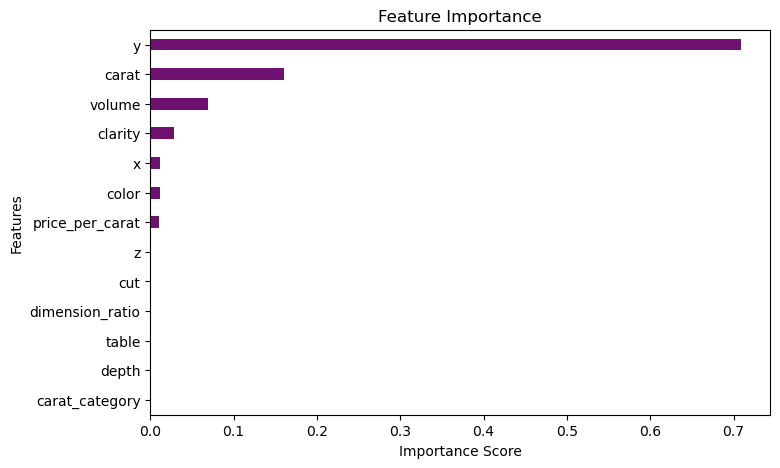

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# sort features by importance
importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance, color='purple', width=0.4)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()


In [25]:
feature_importance = ["y", "carat", "volume", "clarity", "x", "color", "price_per_carat", "price_inr"]

In [26]:
filtered1 = data[feature_importance] # original data

filtered1.head()

,y,carat,volume,clarity,x,color,price_per_carat,price_inr
0,3.98,0.207014,38.202030,2,3.95,6,27.968908,480.566694
1,3.84,0.190620,34.505856,3,3.89,6,30.374301,480.566694
2,4.07,0.207014,38.076885,5,4.05,6,27.983657,480.820129
3,4.23,0.254642,46.724580,4,4.20,2,22.832547,482.572834
4,4.35,0.270027,51.917250,2,4.34,1,21.542691,482.820226


In [27]:
filtered1.to_csv("regression.csv", index=False)